# Ensemble A — 2020 Presidential Election (Biden vs. Trump)

This notebook runs the ReCom ensemble scored on the 2020 presidential results (`PRES20D` / `PRES20R`).
Load the cleaned shapefile from `data/cleaned/pa_cleaned_precincts/` before running.


In [18]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from functools import partial

from gerrychain import Graph, Partition, Election, MarkovChain
from gerrychain.updaters import (
    Tally, cut_edges, cut_edges_by_part,
    boundary_nodes, exterior_boundaries, interior_boundaries, perimeter,
)
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.metrics import polsby_popper

## Step 1 — Load Cleaned Shapefile

Shape: (9150, 12)
Columns: ['COUNTYFP', 'TOTPOP', 'VAP', 'BVAP', 'WVAP', 'HVAP', 'PRES20D', 'PRES20R', 'PRES16D', 'PRES16R', 'SENDIST', 'geometry']
CRS: EPSG:32618
Districts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


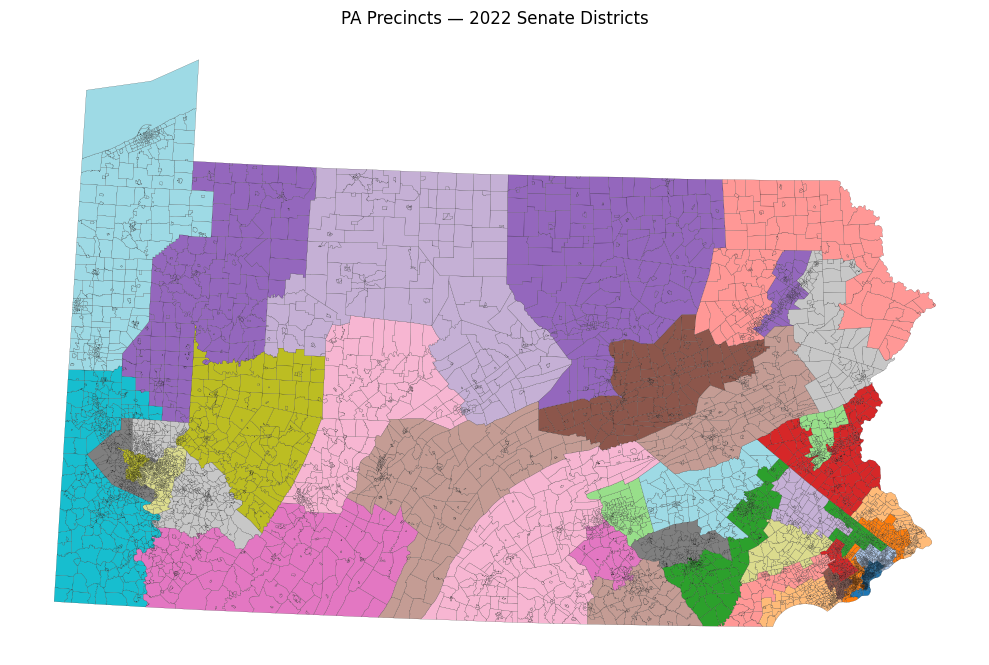

In [19]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
shp_path = os.path.join(BASE_DIR, "data", "cleaned", "pa_cleaned_precincts", "pa_cleaned_precincts.shp")

precincts = gpd.read_file(shp_path)
precincts["SENDIST"] = precincts["SENDIST"].astype(int)

print("Shape:", precincts.shape)
print("Columns:", list(precincts.columns))
print("CRS:", precincts.crs)
print("Districts:", sorted(precincts["SENDIST"].unique()))
precincts.plot(column="SENDIST", figsize=(10, 8), cmap="tab20", edgecolor="black", linewidth=0.1, legend=False)
plt.title("PA Precincts — 2022 Senate Districts")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2 — Build Dual Graph and Initial Partition

In [20]:
graph = Graph.from_geodataframe(precincts)
print("Nodes:", graph.number_of_nodes(), "| Edges:", graph.number_of_edges())

election = Election("PRES20", {"Dem": "PRES20D", "Rep": "PRES20R"})

initial_partition = Partition(
    graph,
    assignment="SENDIST",
    updaters={
        "cut_edges": cut_edges,
        "cut_edges_by_part": cut_edges_by_part,
        "population": Tally("TOTPOP", alias="population"),
        "PRES20": election,
        "area": Tally("area", alias="area"),
        "boundary_nodes": boundary_nodes,
        "exterior_boundaries": exterior_boundaries,
        "interior_boundaries": interior_boundaries,
        "perimeter": perimeter,
    },
)

pops = sorted(initial_partition["population"].values())
print(f"Number of districts: {len(initial_partition)}")
print(f"Total population: {sum(pops):,}")
print(f"Ideal district population: {sum(pops)/len(initial_partition):,.0f}")
print(f"Min district pop: {min(pops):,}  |  Max: {max(pops):,}")
print(f"Enacted Dem seats (2020): {initial_partition['PRES20'].seats('Dem')}")

Nodes: 9150 | Edges: 25272
Number of districts: 50
Total population: 13,002,700
Ideal district population: 260,054
Min district pop: 248,775  |  Max: 270,863
Enacted Dem seats (2020): 25


## Step 3 — Configure and Run ReCom Ensemble

- **Population tolerance:** 5 % of ideal district size (enacted plan deviates up to ~4.3 %, so 2 % would reject the initial state)
- **Steps:** 50 000 / 100 000 (two chains for convergence comparison)
- **Proposal:** ReCom — random spanning tree, split on a population-balanced edge

In [21]:
POP_TOLERANCE = 0.05  # 5% — enacted plan deviates up to ~4.3% from ideal
NUM_STEPS = 50000

ideal_pop = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=POP_TOLERANCE,
    node_repeats=2,
)

chain = MarkovChain(
    proposal=proposal,
    constraints=[within_percent_of_ideal_population(initial_partition, POP_TOLERANCE)],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=NUM_STEPS,
)

dem_seats_list = []
dem_vote_shares_list = []
cut_edges_list = []
polsby_popper_list = []

for i, partition in enumerate(chain):
    dem_seats_list.append(partition["PRES20"].seats("Dem"))
    dem_vote_shares_list.append(list(partition["PRES20"].percents("Dem")))
    cut_edges_list.append(len(partition["cut_edges"]))
    pp = polsby_popper(partition)
    polsby_popper_list.append([pp[k] for k in sorted(pp.keys())])
    if (i + 1) % 100 == 0:
        print(f"  step {i+1}/{NUM_STEPS}")

dem_seats = np.array(dem_seats_list)
dem_vote_shares = np.array(dem_vote_shares_list)
dem_vote_shares_sorted = np.sort(dem_vote_shares, axis=1)

print(f"\nDone. Collected {len(dem_seats)} plans.")
print(f"Dem seat range: {dem_seats.min()} – {dem_seats.max()}  |  median: {np.median(dem_seats):.0f}")

  step 100/50000
  step 200/50000
  step 300/50000
  step 400/50000
  step 500/50000
  step 600/50000
  step 700/50000
  step 800/50000
  step 900/50000
  step 1000/50000
  step 1100/50000
  step 1200/50000
  step 1300/50000
  step 1400/50000
  step 1500/50000
  step 1600/50000
  step 1700/50000
  step 1800/50000
  step 1900/50000
  step 2000/50000
  step 2100/50000
  step 2200/50000
  step 2300/50000
  step 2400/50000
  step 2500/50000
  step 2600/50000
  step 2700/50000
  step 2800/50000
  step 2900/50000
  step 3000/50000
  step 3100/50000
  step 3200/50000
  step 3300/50000
  step 3400/50000
  step 3500/50000
  step 3600/50000
  step 3700/50000
  step 3800/50000
  step 3900/50000
  step 4000/50000
  step 4100/50000
  step 4200/50000
  step 4300/50000
  step 4400/50000
  step 4500/50000
  step 4600/50000
  step 4700/50000
  step 4800/50000
  step 4900/50000
  step 5000/50000
  step 5100/50000
  step 5200/50000
  step 5300/50000
  step 5400/50000
  step 5500/50000
  step 5600/50000
 

In [22]:
POP_TOLERANCE = 0.05
NUM_STEPS_2 = 100000

proposal2 = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=POP_TOLERANCE,
    node_repeats=2,
)

chain2 = MarkovChain(
    proposal=proposal2,
    constraints=[within_percent_of_ideal_population(initial_partition, POP_TOLERANCE)],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=NUM_STEPS_2,
)

dem_seats_list_2 = []
dem_vote_shares_list_2 = []
cut_edges_list_2 = []
polsby_popper_list_2 = []

for i, partition in enumerate(chain2):
    dem_seats_list_2.append(partition["PRES20"].seats("Dem"))
    dem_vote_shares_list_2.append(list(partition["PRES20"].percents("Dem")))
    cut_edges_list_2.append(len(partition["cut_edges"]))
    pp = polsby_popper(partition)
    polsby_popper_list_2.append([pp[k] for k in sorted(pp.keys())])
    if (i + 1) % 200 == 0:
        print(f"  step {i+1}/{NUM_STEPS_2}")

dem_seats_2 = np.array(dem_seats_list_2)
dem_vote_shares_2 = np.array(dem_vote_shares_list_2)
dem_vote_shares_sorted_2 = np.sort(dem_vote_shares_2, axis=1)

print(f"\nDone. Collected {len(dem_seats_2)} plans.")
print(f"Dem seat range: {dem_seats_2.min()} – {dem_seats_2.max()}  |  median: {np.median(dem_seats_2):.0f}")

  step 200/100000
  step 400/100000
  step 600/100000
  step 800/100000
  step 1000/100000
  step 1200/100000
  step 1400/100000
  step 1600/100000
  step 1800/100000
  step 2000/100000
  step 2200/100000
  step 2400/100000
  step 2600/100000
  step 2800/100000
  step 3000/100000
  step 3200/100000
  step 3400/100000
  step 3600/100000
  step 3800/100000
  step 4000/100000
  step 4200/100000
  step 4400/100000
  step 4600/100000
  step 4800/100000
  step 5000/100000
  step 5200/100000
  step 5400/100000
  step 5600/100000
  step 5800/100000
  step 6000/100000
  step 6200/100000
  step 6400/100000
  step 6600/100000
  step 6800/100000
  step 7000/100000
  step 7200/100000
  step 7400/100000
  step 7600/100000
  step 7800/100000
  step 8000/100000
  step 8200/100000
  step 8400/100000
  step 8600/100000
  step 8800/100000
  step 9000/100000
  step 9200/100000
  step 9400/100000
  step 9600/100000
  step 9800/100000
  step 10000/100000
  step 10200/100000
  step 10400/100000
  step 10600/

## Step 4 — Plot Results

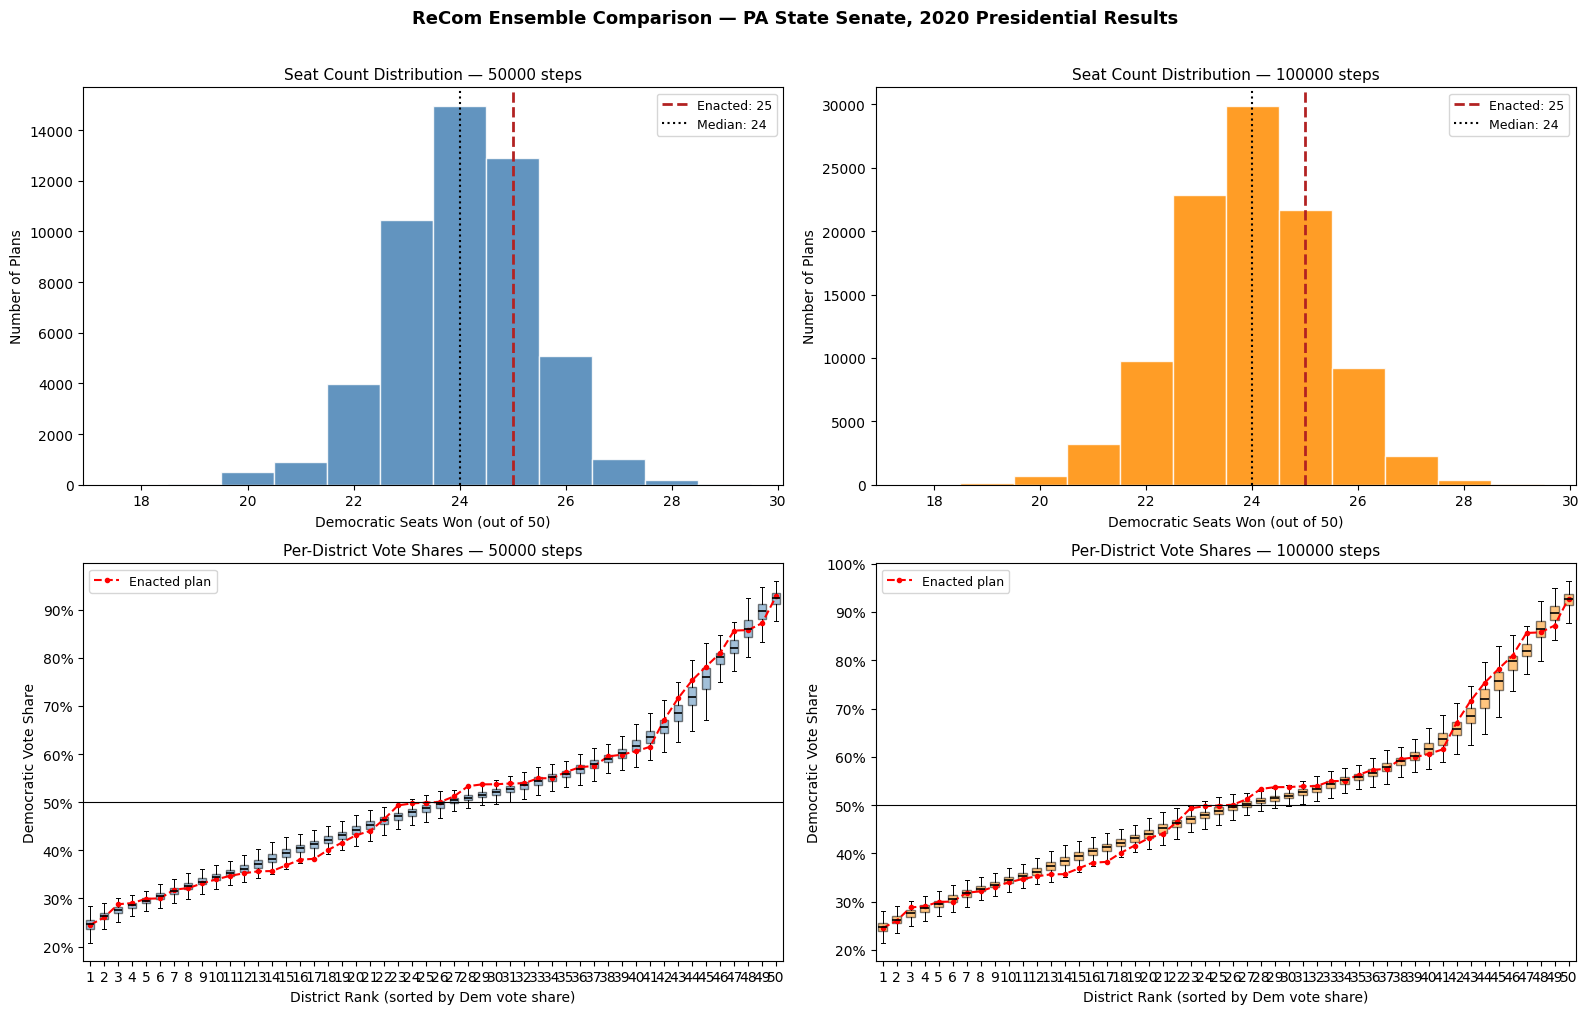

In [23]:
enacted_seats = initial_partition["PRES20"].seats("Dem")
enacted_percents = sorted(initial_partition["PRES20"].percents("Dem"))

# Rebuild clean arrays from both chain lists (safe to re-run even if variables were overwritten)
s1 = np.array(dem_seats_list)
vs1 = np.sort(np.array(dem_vote_shares_list), axis=1)
s2 = np.array(dem_seats_list_2)
vs2 = np.sort(np.array(dem_vote_shares_list_2), axis=1)

chains = [
    (s1, vs1, f"{NUM_STEPS} steps", "steelblue"),
    (s2, vs2, f"{NUM_STEPS_2} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (seats, vs_sorted, label, color) in enumerate(chains):
    # --- row 0: seat-count histogram ---
    ax = axes[0, col]
    all_seats = np.concatenate([s1, s2])
    bins = np.arange(all_seats.min() - 0.5, all_seats.max() + 1.5, 1)
    ax.hist(seats, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_seats, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_seats}")
    ax.axvline(np.median(seats), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(seats):.0f}")
    ax.set_xlabel("Democratic Seats Won (out of 50)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Seat Count Distribution — {label}", fontsize=11)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # --- row 1: sorted vote-share box plot ---
    ax2 = axes[1, col]
    n_dist = vs_sorted.shape[1]
    ax2.boxplot(
        [vs_sorted[:, i] for i in range(n_dist)],
        positions=range(1, n_dist + 1),
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(linewidth=0.7),
        capprops=dict(linewidth=0.7),
        showfliers=False,
    )
    ax2.plot(range(1, len(enacted_percents) + 1), enacted_percents,
             "r--o", markersize=3, linewidth=1.5, label="Enacted plan")
    ax2.axhline(0.5, color="black", linewidth=0.8)
    ax2.set_xlabel("District Rank (sorted by Dem vote share)", fontsize=10)
    ax2.set_ylabel("Democratic Vote Share", fontsize=10)
    ax2.set_title(f"Per-District Vote Shares — {label}", fontsize=11)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax2.legend(fontsize=9)

plt.suptitle("ReCom Ensemble Comparison — PA State Senate, 2020 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Step 4b — Efficiency Gap & Cut Edges

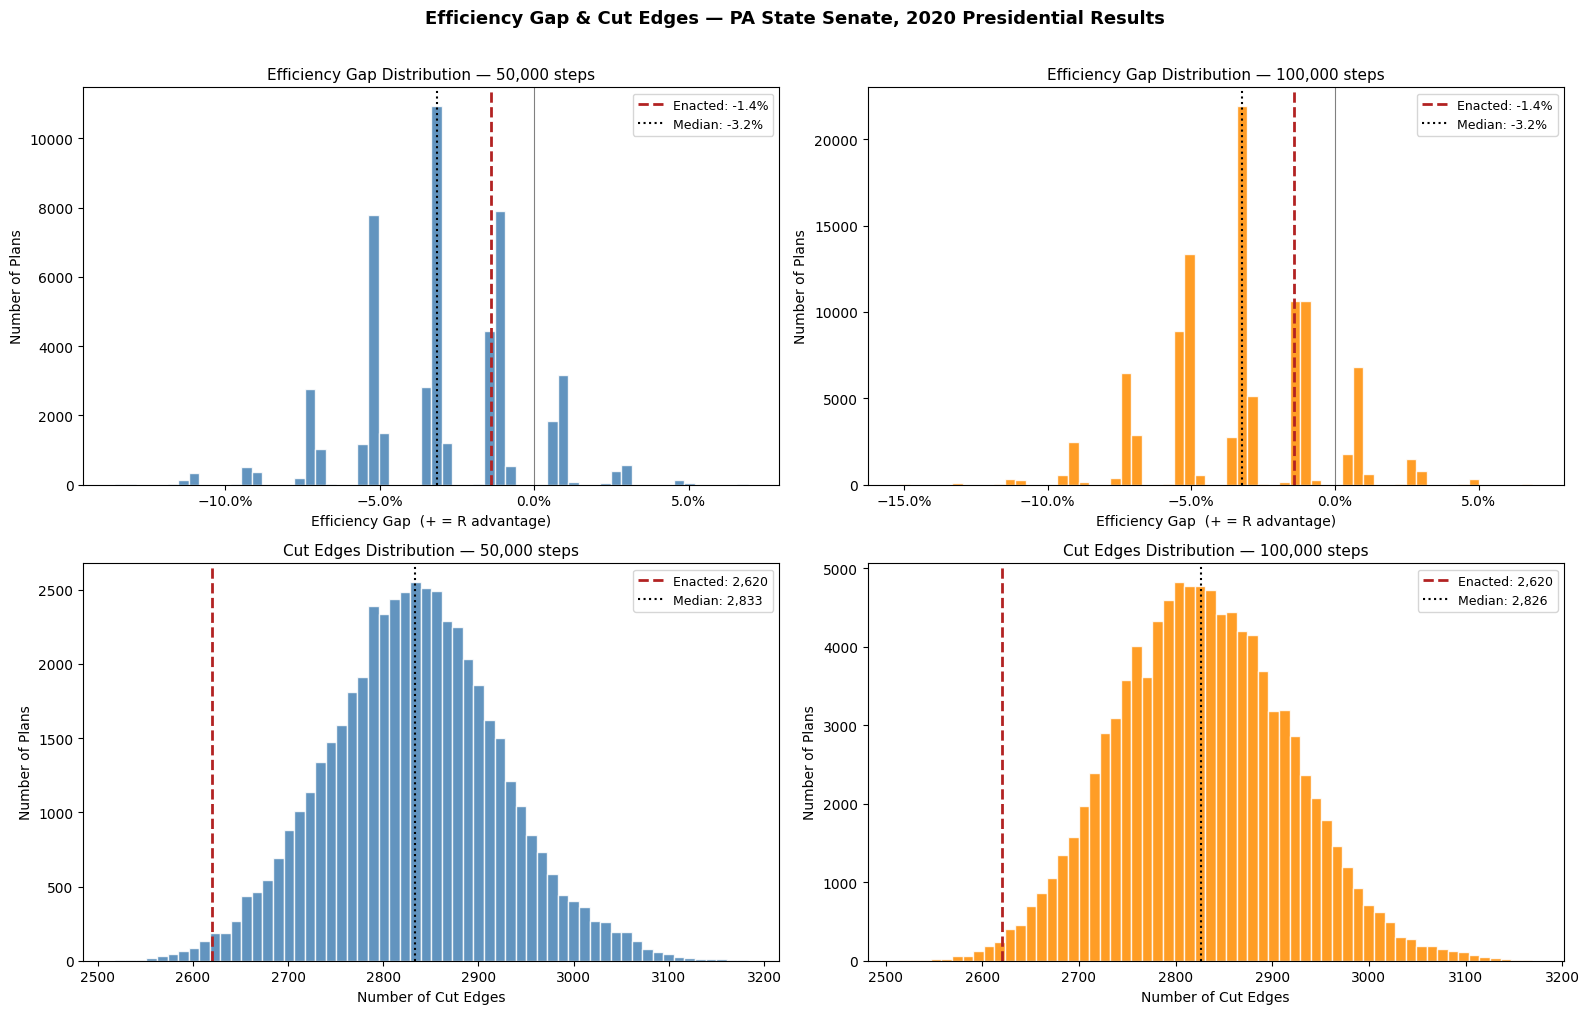

In [27]:
def efficiency_gap(vote_shares):
    """Positive = Republican advantage, negative = Democratic advantage."""
    vs = np.asarray(vote_shares)
    wasted_d = np.where(vs > 0.5, vs - 0.5, vs)
    wasted_r = np.where(vs > 0.5, 1 - vs, 0.5 - vs)
    return (wasted_r.sum() - wasted_d.sum()) / len(vs)

# EG computed from already-collected vote share data — no rerun needed
eg1 = np.array([efficiency_gap(row) for row in dem_vote_shares_list])
eg2 = np.array([efficiency_gap(row) for row in dem_vote_shares_list_2])

# Cut edges collected during the chain runs
ce1 = np.array(cut_edges_list)
ce2 = np.array(cut_edges_list_2)

# Enacted values
enacted_eg = efficiency_gap(list(initial_partition["PRES20"].percents("Dem")))
enacted_ce = len(initial_partition["cut_edges"])

chains = [
    (eg1, ce1, f"{NUM_STEPS:,} steps",   "steelblue"),
    (eg2, ce2, f"{NUM_STEPS_2:,} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (eg, ce, label, color) in enumerate(chains):
    # --- row 0: efficiency gap ---
    ax = axes[0, col]
    ax.hist(eg, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_eg, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_eg:.1%}")
    ax.axvline(np.median(eg), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(eg):.1%}")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Efficiency Gap  (+ = R advantage)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Efficiency Gap Distribution — {label}", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

    # --- row 1: cut edges ---
    ax2 = axes[1, col]
    ax2.hist(ce, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax2.axvline(enacted_ce, color="firebrick", linewidth=2, linestyle="--",
                label=f"Enacted: {enacted_ce:,}")
    ax2.axvline(np.median(ce), color="black", linewidth=1.5, linestyle=":",
                label=f"Median: {np.median(ce):,.0f}")
    ax2.set_xlabel("Number of Cut Edges", fontsize=10)
    ax2.set_ylabel("Number of Plans", fontsize=10)
    ax2.set_title(f"Cut Edges Distribution — {label}", fontsize=11)
    ax2.legend(fontsize=9)

plt.suptitle("Efficiency Gap & Cut Edges — PA State Senate, 2020 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

out_dir = os.path.join(BASE_DIR, "data", "ensemble_results")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "ensemble_A_efficiency_gap_cut_edges.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 4c — Polsby-Popper Compactness

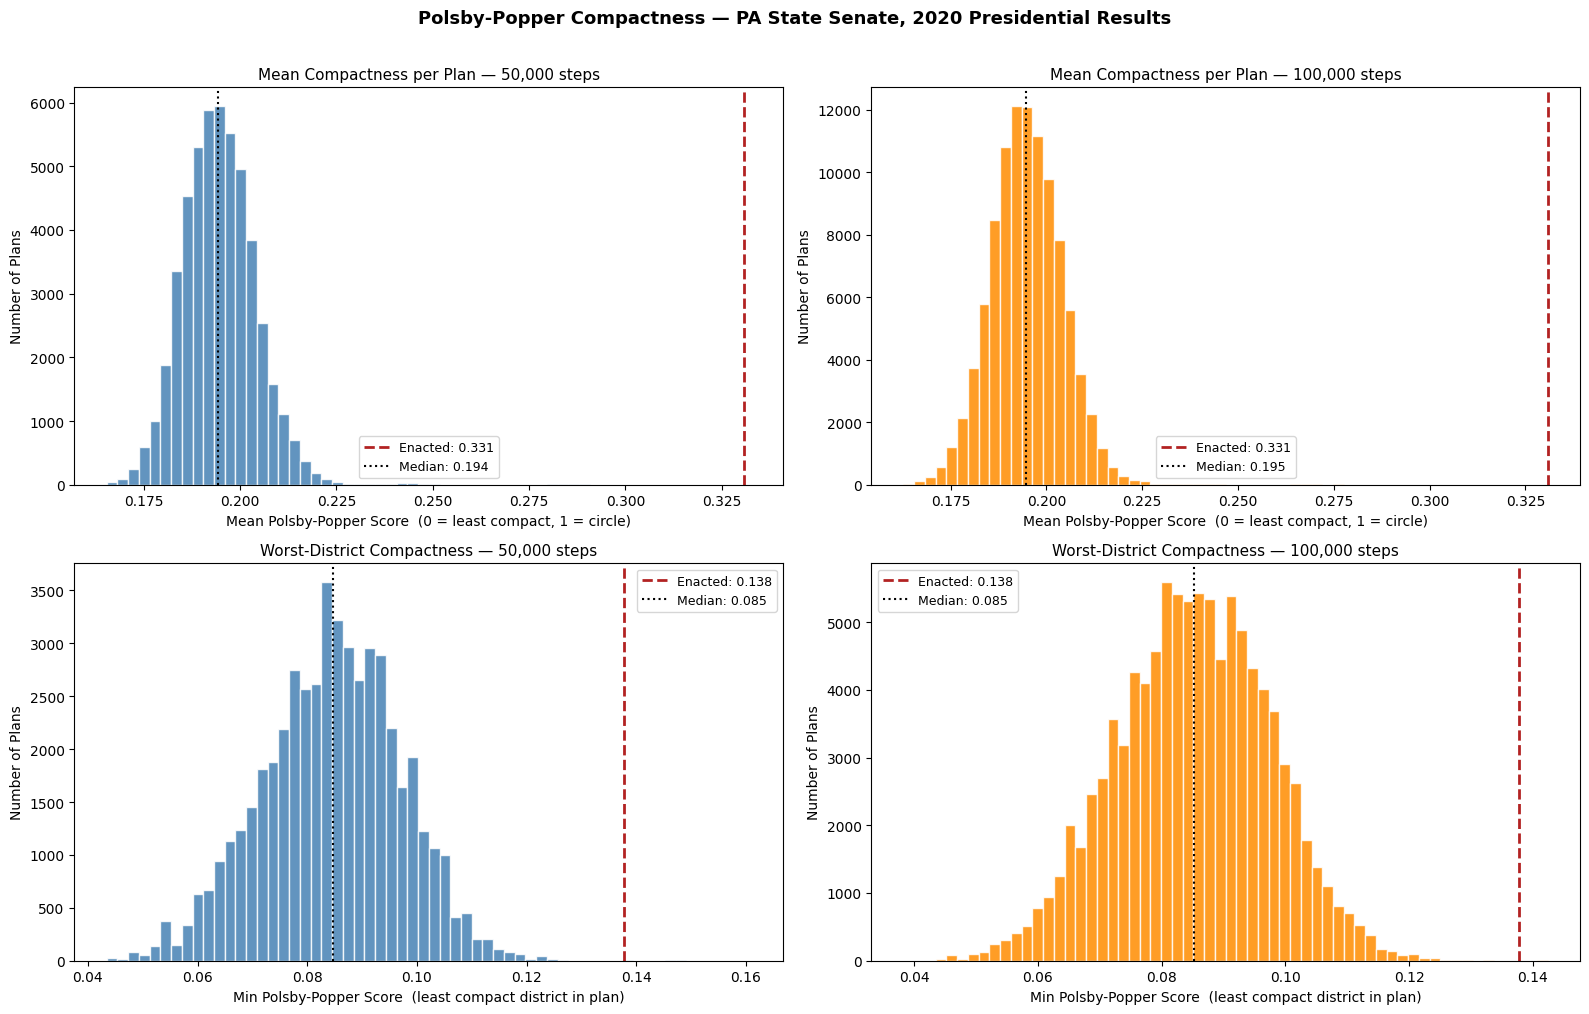

In [28]:
pp_arr1 = np.array(polsby_popper_list)    # shape (NUM_STEPS, 50)
pp_arr2 = np.array(polsby_popper_list_2)  # shape (NUM_STEPS_2, 50)

mean_pp1, min_pp1 = pp_arr1.mean(axis=1), pp_arr1.min(axis=1)
mean_pp2, min_pp2 = pp_arr2.mean(axis=1), pp_arr2.min(axis=1)

enacted_pp_vals = list(polsby_popper(initial_partition).values())
enacted_pp_mean = np.mean(enacted_pp_vals)
enacted_pp_min  = np.min(enacted_pp_vals)

chains = [
    (mean_pp1, min_pp1, f"{NUM_STEPS:,} steps",   "steelblue"),
    (mean_pp2, min_pp2, f"{NUM_STEPS_2:,} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (mean_pp, min_pp, label, color) in enumerate(chains):
    # --- row 0: mean PP per plan ---
    ax = axes[0, col]
    ax.hist(mean_pp, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_pp_mean, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_pp_mean:.3f}")
    ax.axvline(np.median(mean_pp), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(mean_pp):.3f}")
    ax.set_xlabel("Mean Polsby-Popper Score  (0 = least compact, 1 = circle)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Mean Compactness per Plan — {label}", fontsize=11)
    ax.legend(fontsize=9)

    # --- row 1: min PP per plan (least compact district) ---
    ax2 = axes[1, col]
    ax2.hist(min_pp, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax2.axvline(enacted_pp_min, color="firebrick", linewidth=2, linestyle="--",
                label=f"Enacted: {enacted_pp_min:.3f}")
    ax2.axvline(np.median(min_pp), color="black", linewidth=1.5, linestyle=":",
                label=f"Median: {np.median(min_pp):.3f}")
    ax2.set_xlabel("Min Polsby-Popper Score  (least compact district in plan)", fontsize=10)
    ax2.set_ylabel("Number of Plans", fontsize=10)
    ax2.set_title(f"Worst-District Compactness — {label}", fontsize=11)
    ax2.legend(fontsize=9)

plt.suptitle("Polsby-Popper Compactness — PA State Senate, 2020 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

out_dir = os.path.join(BASE_DIR, "data", "ensemble_results")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "ensemble_A_polsby_popper.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Save Ensemble Results

In [29]:
out_dir = os.path.join(BASE_DIR, "data", "ensemble_results")
os.makedirs(out_dir, exist_ok=True)

# --- Chain 1 (50k steps) ---
pd.DataFrame({"dem_seats": dem_seats_list}).to_csv(
    os.path.join(out_dir, "ensemble_A_50000_seats.csv"), index=False
)
pd.DataFrame(np.sort(np.array(dem_vote_shares_list), axis=1),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_A_50000_vote_shares.csv"), index=False
)
pd.DataFrame({"cut_edges": cut_edges_list}).to_csv(
    os.path.join(out_dir, "ensemble_A_50000_cut_edges.csv"), index=False
)
pd.DataFrame(np.array(polsby_popper_list),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_A_50000_polsby_popper.csv"), index=False
)

# --- Chain 2 (100k steps) ---
pd.DataFrame({"dem_seats": dem_seats_list_2}).to_csv(
    os.path.join(out_dir, "ensemble_A_100000_seats.csv"), index=False
)
pd.DataFrame(np.sort(np.array(dem_vote_shares_list_2), axis=1),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_A_100000_vote_shares.csv"), index=False
)
pd.DataFrame({"cut_edges": cut_edges_list_2}).to_csv(
    os.path.join(out_dir, "ensemble_A_100000_cut_edges.csv"), index=False
)
pd.DataFrame(np.array(polsby_popper_list_2),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_A_100000_polsby_popper.csv"), index=False
)

print("Saved results to", out_dir)

Saved results to c:\Users\elyas\OneDrive\Documents\GitHub\AI_For_Redistricting_Project\data\ensemble_results
